# Protein Language Models for Structural Proteins
## Hands-on with **ESMC** and **ESMFold2** (EvolutionaryScale / Biohub)

*Focus: silk and other structural/biomaterials proteins.*

### Markus J. Buehler, MIT

Modern protein language models (pLMs) learn the "grammar" of protein sequences from
hundreds of millions of natural proteins. In this notebook we use two of the newest open models:

| Model | What it does | We use |
|-------|--------------|--------|
| **ESMC** (300M / 600M / 6B) | A masked protein **language model** → per-residue & whole-protein *embeddings*, masked-residue prediction, variant scoring | `biohub/ESMC-300M` (runs on a laptop), optionally 600M/6B |
| **ESMFold2 / ESMFold2-Fast** | **Structure prediction** → all-atom 3-D coordinates + confidence (pLDDT, pTM) | `biohub/ESMFold2-Fast` |

### What you will learn
1. Turn a protein sequence into a numerical **embedding** and see what it captures.
2. Map the **embedding space** of silk, collagen, elastin, resilin … and see materials cluster.
3. Use **masked language modeling** to show ESMC has internalized the *repeat grammar* of spider silk.
4. Compute per-residue **"naturalness"** and an in-silico **deep mutational scan**.
5. Read **attention maps** to see the model "find" the periodicity of silk repeats.
6. **Fold** a silk peptide with ESMFold2 and visualize it in 3-D, colored by confidence.

### Why structural proteins?
Silk, collagen, elastin, and resilin are **biomaterials**: their mechanics come from short
sequence *motifs* arranged in long repeats. That makes them an ideal lens for asking
*"what has a protein language model actually learned?"*

| Material | Signature motif | Structural role |
|----------|-----------------|-----------------|
| Spider dragline (MaSp1) | poly-Ala `(A)n` + `GGX` | β-sheet nanocrystals + amorphous matrix |
| Spider dragline (MaSp2) | `GPGGY`/`GPGQQ` + poly-Ala | elastic β-spirals + crystals |
| Silkworm fibroin | `GAGAGS` | antiparallel β-sheet crystallites |
| Collagen | `Gly-X-Y` (often `GPP`) | triple helix |
| Elastin | `VPGVG` | elastomeric β-turns |
| Resilin | `PSDSYGAP` | near-perfect rubber elasticity |


## 0 · Setup & environment

This notebook is meant to run in the dedicated **`esm`** conda environment, which has the
EvolutionaryScale `esm` SDK (which installs a patched `transformers` that registers the
`esmc` and `esmfold2` architectures), plus `torch`, `py3Dmol`, `scikit-learn`, `matplotlib`.

```bash
conda create -n esm python=3.12 -y
conda activate esm
pip install "esm @ git+https://github.com/Biohub/esm.git@c94ed8d" jupyter ipykernel py3Dmol scikit-learn matplotlib
python -m ipykernel install --user --name esm --display-name "Python (esm)"
```
Then pick the **Python (esm — ESMC/ESMFold2)** kernel.

The code auto-detects your hardware: **CUDA** GPU → **Apple-Silicon MPS** → **CPU**. ESMC-300M
runs fine on CPU/MPS; ESMFold2 is heavier (it uses the 6B ESMC backbone) — best with lots of RAM or a GPU.

In [1]:
import os
# Let any op without an MPS kernel fall back to CPU instead of erroring (Apple Silicon).
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import torch, numpy as np, matplotlib.pyplot as plt

def get_device():
    if torch.cuda.is_available(): return "cuda"
    if torch.backends.mps.is_available(): return "mps"
    return "cpu"

DEVICE = get_device()
print("PyTorch", torch.__version__, "| device:", DEVICE)

# Every figure is saved under results/ as BOTH .png (for slides/docs) and .svg (vector).
from pathlib import Path
RESULTS = Path("results"); RESULTS.mkdir(exist_ok=True)
def savefig(fig, name):
    for ext in ("png", "svg"):
        fig.savefig(RESULTS / f"{name}.{ext}", dpi=150, bbox_inches="tight")
    print("saved:", RESULTS / f"{name}.png", "and .svg")

PyTorch 2.12.0 | device: mps


## 1 · A library of structural-protein sequences

We mix three kinds of sequences:

* **Consensus repeat constructs** — short, idealized repeats that make each material's
  motif obvious (great for teaching the "grammar").
* **Real proteins** — fetched live from **UniProt** by accession, so nothing is hand-typed
  or fabricated. (Spidroins are huge and exceed ESMC's 2048-token window, so we use a slice.)
* **Globular controls** — well-folded, *non-repetitive* proteins (ubiquitin, GFP) for contrast.

In [2]:
import urllib.request

# ---- consensus repeat constructs (teaching-oriented) ----
CONSENSUS = {
    "MaSp1 repeat":      "GGAGQGGYGGLGSQGAGRGGLGGQGAGAAAAAAAA" * 2,   # dragline: GGX + poly-Ala
    "MaSp2 repeat":      "GPGGYGPGQQGPGGYGPGQQGPSGPGSAAAAAAAA" * 2,   # dragline: GPGXX + poly-Ala
    "Flagelliform":      "GPGGAGPGGAGPGGAGPGGAGGPYGPGGSGPGGYGPGGSG" * 2,  # capture silk: elastic
    "Fibroin (GAGAGS)":  "GAGAGS" * 12,                                # silkworm crystallite
    "Collagen (GPP)":    "GPP" * 24,                                   # triple helix
    "Elastin (VPGVG)":   "VPGVG" * 14,                                 # elastomer
    "Resilin":           "GGRPSDSYGAPGGGN" * 5,                        # insect rubber
    "Poly-Ala":          "A" * 40,                                     # pure β-crystal
}

# ---- real proteins (fetched from UniProt) ----
UNIPROT = {
    "P19837": "MaSp1 (spider dragline)",
    "P46804": "MaSp2 (spider dragline)",
    "P05790": "Fibroin H (silkworm)",
    "P15502": "Elastin (human)",
    "P02452": "Collagen-I (human)",
    "Q9V7U0": "Pro-resilin (fly)",
}

# ---- globular, non-repetitive controls ----
CONTROLS = {
    "Ubiquitin": "MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG",
    "GFP": ("MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFSYGVQCFSRYP"
            "DHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNV"
            "YIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVT"
            "AAGITHGMDELYK"),
}

# ---- many well-folded GLOBULAR proteins (for clean clustering) ----
GLOBULAR = {
    "P61626": "Lysozyme C (human)",       "P00698": "Lysozyme C (hen egg)",
    "P02144": "Myoglobin (human)",        "P69905": "Hemoglobin alpha (human)",
    "P99999": "Cytochrome c (human)",     "P01308": "Insulin (human)",
    "P00918": "Carbonic anhydrase 2",     "P0DP23": "Calmodulin (human)",
    "P60174": "Triosephosphate isomerase","P00760": "Trypsin (bovine)",
    "P0AGE0": "ssDNA-binding (E. coli)",  "P0A7Y4": "RNase HI (E. coli)",
}

# ---- a few extra structural / fibrous proteins ----
STRUCT_EXTRA = {
    "P04264": "Keratin K2C1 (human)",     "P02671": "Fibrinogen alpha (human)",
    "P02461": "Collagen-III (human)",     "P08123": "Collagen-II_a2(I) (human)",
}

def fetch_uniprot(acc):
    """Return the amino-acid sequence for a UniProt accession (no auth needed)."""
    url = f"https://rest.uniprot.org/uniprotkb/{acc}.fasta"
    req = urllib.request.Request(url, headers={"User-Agent": "esm-class-notebook"})
    txt = urllib.request.urlopen(req, timeout=30).read().decode()
    return "".join(txt.splitlines()[1:])

print("Consensus constructs:", ", ".join(CONSENSUS))
print("Will fetch from UniProt:", ", ".join(UNIPROT.values()))

Consensus constructs: MaSp1 repeat, MaSp2 repeat, Flagelliform, Fibroin (GAGAGS), Collagen (GPP), Elastin (VPGVG), Resilin, Poly-Ala
Will fetch from UniProt: MaSp1 (spider dragline), MaSp2 (spider dragline), Fibroin H (silkworm), Elastin (human), Collagen-I (human), Pro-resilin (fly)


In [3]:
# Fetch the real sequences once. Spidroins/fibroin are partial or very long, so we keep a
# central repetitive slice that fits ESMC's 2048-residue context window.
MAXLEN = 400
def fetch_group(accmap):
    out = {}
    for acc, name in accmap.items():
        full = fetch_uniprot(acc)
        mid = len(full) // 2
        out[name] = full[max(0, mid - MAXLEN // 2): mid + MAXLEN // 2]   # central slice
    return out

real_seqs      = fetch_group(UNIPROT)        # silk + fibrous reals
globular_seqs  = fetch_group(GLOBULAR)       # well-folded globular reals
struct_extra   = fetch_group(STRUCT_EXTRA)   # extra fibrous reals
for name, s in {**real_seqs, **globular_seqs, **struct_extra}.items():
    print(f"{name:28} using {len(s):3d} aa   {s[:42]}...")
print(f"\nfetched {len(real_seqs)+len(globular_seqs)+len(struct_extra)} real proteins")

MaSp1 (spider dragline)      using 400 aa   AAGGAGQGGYGGLGGQGAGQGGYGGLGSQGAGRGGLGGQGAG...
MaSp2 (spider dragline)      using 400 aa   AASAAASAESGQQGPGGYGPGQQGPGGYGPGQQGPGGYGPGQ...
Fibroin H (silkworm)         using 400 aa   GAGSGAGAGSGAGAGYGAGYGAGVGAGYGAGAGSGAASGAGA...
Elastin (human)              using 400 aa   PFGGPQPGVPLGYPIKAPKLPGGYGLPYTTGKLPYGYGPGGV...
Collagen-I (human)           using 400 aa   GLPGAKGLTGSPGSPGPDGKTGPPGPAGQDGRPGPPGPPGAR...
Pro-resilin (fly)            using 400 aa   GNGGRPSDTYGAPGGGNGGRPSDTYGAPGGGGNGNGGRPSSS...
Lysozyme C (human)           using 148 aa   MKALIVLGLVLLSVTVQGKVFERCELARTLKRLGMDGYRGIS...
Lysozyme C (hen egg)         using 147 aa   MRSLLILVLCFLPLAALGKVFGRCELAAAMKRHGLDNYRGYS...
Myoglobin (human)            using 154 aa   MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLE...
Hemoglobin alpha (human)     using 142 aa   MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKT...
Cytochrome c (human)         using 105 aa   MGDVEKGKKIFIMKCSQCHTVEKGGKHKTGPNLHGLFGRKTG...
Insulin (h

## 2 · Load ESMC

ESMC is a standard 🤗 `transformers` model, so we load it with `AutoModelForMaskedLM`. The
masked-LM head lets us (a) read **hidden states** = embeddings and (b) predict **masked residues**
and score variants — all from one model.

> **Pick a model size below by un-commenting ONE line.** All three share the same API, so the
> entire notebook works unchanged whichever you choose — only quality, memory, and speed differ.
>
> | variant | params | download | notes |
> |---------|-------:|---------:|-------|
> | `ESMC-300M` | 300M | ~1.3 GB | laptop-friendly default; runs on MPS/CPU |
> | `ESMC-600M` | 600M | ~2.3 GB | sharper; still fine locally |
> | `ESMC-6B`   | 6B   | ~25 GB  | best quality; wants a GPU or lots of RAM (you have 128 GB) |

In [4]:
from transformers import AutoModelForMaskedLM, AutoTokenizer

# ---- Choose an ESMC variant: un-comment exactly ONE line ----
ESMC_MODEL = "biohub/ESMC-300M"      # 300M  ~1.3 GB   (default, runs anywhere)
# ESMC_MODEL = "biohub/ESMC-600M"    # 600M  ~2.3 GB   (sharper, still local-friendly)
# ESMC_MODEL = "biohub/ESMC-6B"      # 6B    ~25 GB    (best quality; GPU or big RAM)

tokenizer = AutoTokenizer.from_pretrained(ESMC_MODEL)
esmc = AutoModelForMaskedLM.from_pretrained(ESMC_MODEL).to(DEVICE).eval()

n_params = sum(p.numel() for p in esmc.parameters())
print(f"Loaded {ESMC_MODEL}: {n_params/1e6:.0f}M parameters on {DEVICE}")
print("Special tokens:", tokenizer.all_special_tokens, "| mask id:", tokenizer.mask_token_id)

# token id for each of the 20 standard amino acids (needed for scoring/mutagenesis)
AAS = "ACDEFGHIKLMNPQRSTVWY"
AA_IDS = {aa: tokenizer.convert_tokens_to_ids(aa) for aa in AAS}
assert all(i is not None and i >= 0 for i in AA_IDS.values())
print("Amino-acid token ids OK:", AA_IDS)

ESMC: transformer_engine is not installed; falling back to pure-PyTorch LayerNorm+Linear / LayerNorm+MLP. Outputs will differ numerically — measured on the unnormalized residual stream (before the final LayerNorm), ~O(10) max-diff in fp32 and ~O(100) in bf16; after the final LayerNorm these shrink to a few ULP and perplexity stays within rounding noise. Install with `pip install transformer-engine[pytorch]` to enable fused fp32-reduction LayerNorm.
ESMC: neither xformers nor flash-attn is installed; falling back to PyTorch ``F.scaled_dot_product_attention``. The attention reduction order in bf16 differs from a fused kernel by ~1 bf16 ULP per attention block; compounded across the 80-block stack this reaches ~O(100) max-diff on the unnormalized residual stream. Install xformers (preferred) with `pip install xformers` for a fused attention kernel.


🚨 No checkpoint found for ESMCForSequenceClassification.forward. Please add a `checkpoint` arg to `auto_docstring` or add one in ESMCConfig's docstring
🚨 No checkpoint found for ESMCForTokenClassification.forward. Please add a `checkpoint` arg to `auto_docstring` or add one in ESMCConfig's docstring
Loaded biohub/ESMC-300M: 333M parameters on mps
Special tokens: ['<cls>', '<eos>', '<unk>', '<pad>', '<mask>', '|'] | mask id: 32
Amino-acid token ids OK: {'A': 5, 'C': 23, 'D': 13, 'E': 9, 'F': 18, 'G': 6, 'H': 21, 'I': 12, 'K': 15, 'L': 4, 'M': 20, 'N': 17, 'P': 14, 'Q': 16, 'R': 10, 'S': 8, 'T': 11, 'V': 7, 'W': 22, 'Y': 19}


## 3 · Sequence → embedding

A protein language model maps every residue to a vector (here **960-dim** for ESMC-300M).
Two views are useful:

* **Per-residue embeddings** `(L, 960)` — one vector per amino acid (good for per-position tasks).
* **Mean-pooled embedding** `(960,)` — one vector for the whole protein (good for comparing proteins).

ESMC adds a `<cls>` token at the start and `<eos>` at the end, so we strip those to keep only residues.

In [5]:
@torch.inference_mode()
def embed(seq, pool="mean"):
    """Return ESMC embeddings for one sequence.
    pool='mean' -> (960,) whole-protein vector; pool='none' -> (L,960) per-residue."""
    inputs = tokenizer(seq, return_tensors="pt").to(DEVICE)
    out = esmc(**inputs, output_hidden_states=True)
    h = out.hidden_states[-1][0]          # (L+2, 960) final-layer hidden states
    per_res = h[1:-1]                      # drop <cls> and <eos> -> (L, 960)
    if pool == "mean":
        return per_res.mean(0).float().cpu().numpy()
    return per_res.float().cpu().numpy()

demo = CONSENSUS["MaSp2 repeat"]
print("sequence length:", len(demo))
print("per-residue embedding:", embed(demo, pool="none").shape)
print("mean-pooled embedding:", embed(demo, pool="mean").shape)

sequence length: 70
per-residue embedding: (70, 960)
mean-pooled embedding: (960,)


## 4 · The embedding space of structural proteins

If ESMC understands protein "chemistry", then proteins with similar composition/structure
should land near each other in embedding space. Let's embed our whole library and look at
(a) a **cosine-similarity heatmap** and (b) a 2-D **PCA** map.

In [6]:
# assemble {label: (sequence, family)} for everything we have
SILK_CONSENSUS = {"MaSp1 repeat","MaSp2 repeat","Flagelliform","Fibroin (GAGAGS)","Poly-Ala"}
library = {}
for k, s in CONSENSUS.items():
    library[k] = (s, "silk" if k in SILK_CONSENSUS else "other-structural")
for name, s in real_seqs.items():
    library[name] = (s, "silk" if any(t in name for t in ["MaSp", "Fibroin"]) else "other-structural")
for name, s in struct_extra.items():
    library[name] = (s, "other-structural")
for name, s in globular_seqs.items():
    library[name] = (s, "globular")
for k, s in CONTROLS.items():
    library[k] = (s, "globular")

labels = list(library)
embs = np.stack([embed(library[l][0], pool="mean") for l in labels])
fams = [library[l][1] for l in labels]
print("embedded", len(labels), "proteins ->", embs.shape)
print("families:", {f: fams.count(f) for f in sorted(set(fams))})

embedded 32 proteins -> (32, 960)
families: {'globular': 14, 'other-structural': 10, 'silk': 8}


saved: results/04_embedding_cosine_heatmap.png and .svg


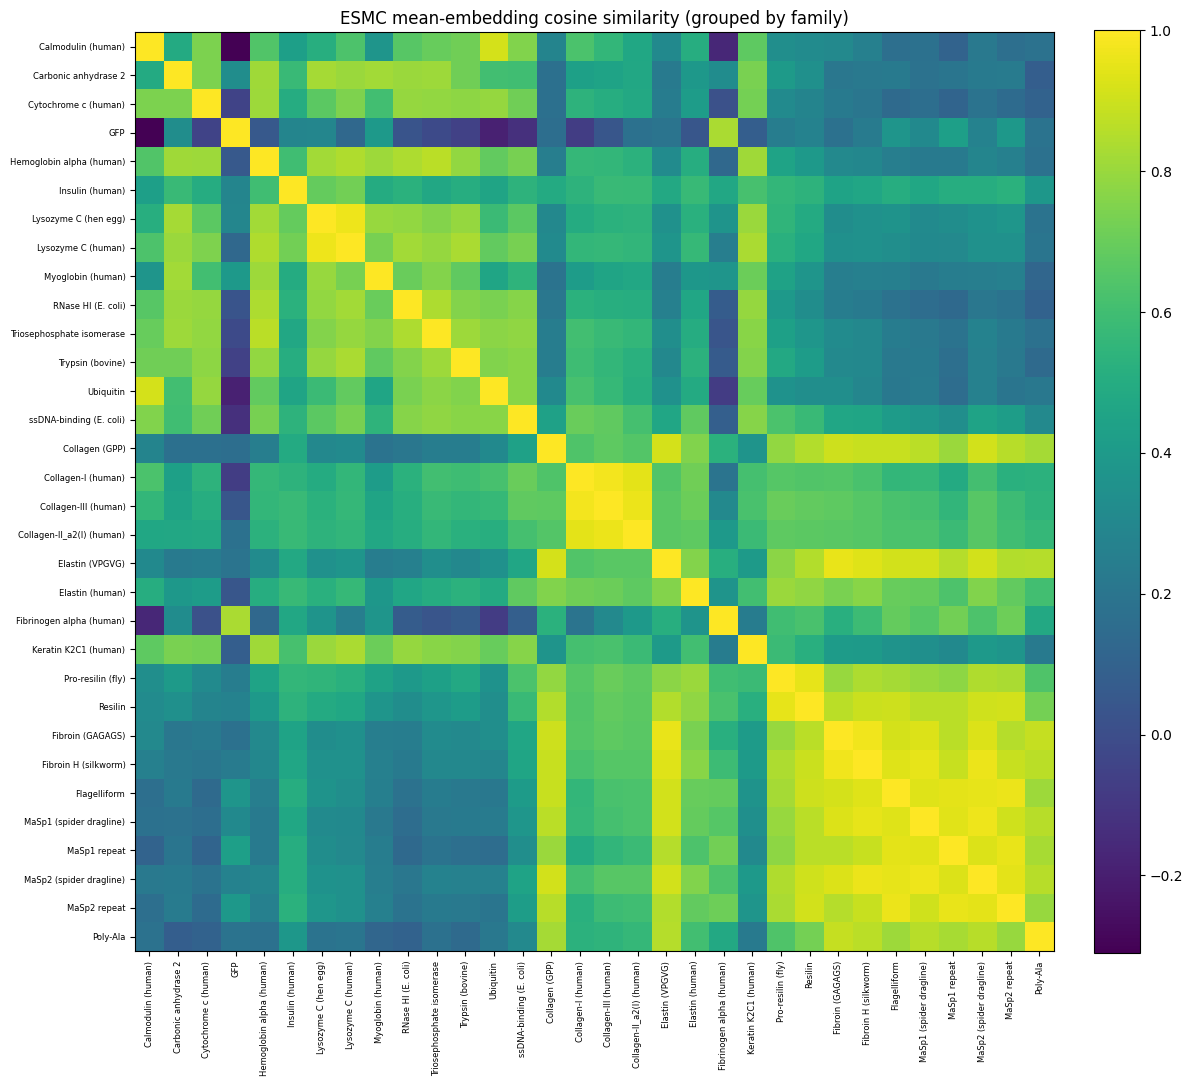

In [7]:
# cosine-similarity heatmap
def cosine_matrix(X):
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)
    return Xn @ Xn.T

# order rows/cols by family so blocks are visible
order = sorted(range(len(labels)), key=lambda i: (fams[i], labels[i]))
S = cosine_matrix(embs)[np.ix_(order, order)]
olabels = [labels[i] for i in order]
fig, ax = plt.subplots(figsize=(12, 11))
im = ax.imshow(S, cmap="viridis")
ax.set_xticks(range(len(olabels))); ax.set_xticklabels(olabels, rotation=90, fontsize=6)
ax.set_yticks(range(len(olabels))); ax.set_yticklabels(olabels, fontsize=6)
ax.set_title("ESMC mean-embedding cosine similarity (grouped by family)")
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout()
savefig(fig, "04_embedding_cosine_heatmap"); plt.show()

saved: results/04_embedding_pca.png and .svg


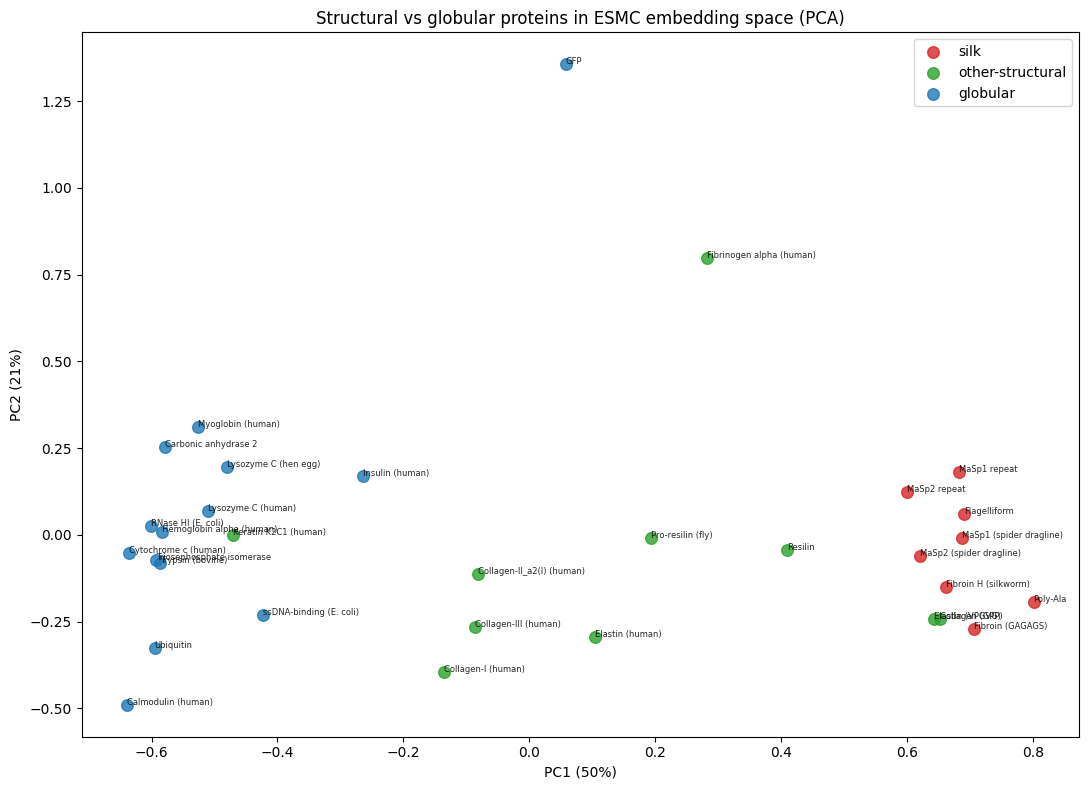

In [8]:
# 2-D PCA of the embeddings, colored by family
from sklearn.decomposition import PCA
pca = PCA(n_components=2).fit(embs)
xy = pca.transform(embs)
colors = {"silk": "tab:red", "other-structural": "tab:green", "globular": "tab:blue"}

fig, ax = plt.subplots(figsize=(11, 8))
for fam in colors:
    idx = [i for i, f in enumerate(fams) if f == fam]
    ax.scatter(xy[idx, 0], xy[idx, 1], c=colors[fam], label=fam, s=70, alpha=0.8)
for i, l in enumerate(labels):
    ax.annotate(l, (xy[i, 0], xy[i, 1]), fontsize=6, alpha=0.85)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
ax.set_title("Structural vs globular proteins in ESMC embedding space (PCA)")
ax.legend(); plt.tight_layout()
savefig(fig, "04_embedding_pca"); plt.show()

## 5 · Masked language modeling: does ESMC know the silk "grammar"?

ESMC was trained by masking residues and predicting them. We can probe what it learned by
hiding a residue inside a silk motif and asking for its top predictions. In the MaSp2 motif
`...GPGGYGPG[Q]Q...`, a model that learned spider-silk repeats should confidently fill in the
right residue.

In [9]:
@torch.inference_mode()
def predict_masked(seq, pos, topk=6):
    """Mask residue at 0-based `pos`, return top-k (residue, probability)."""
    ids = tokenizer(seq, return_tensors="pt")["input_ids"]
    tpos = pos + 1                                   # +1 for <cls>
    wt = tokenizer.convert_ids_to_tokens(ids[0, tpos].item())
    ids = ids.clone(); ids[0, tpos] = tokenizer.mask_token_id
    out = esmc(input_ids=ids.to(DEVICE))
    probs = out.logits[0, tpos].softmax(-1)
    vals, idx = probs.topk(topk)
    preds = [(tokenizer.convert_ids_to_tokens(i.item()), float(v)) for v, i in zip(vals, idx)]
    return wt, preds

seq = CONSENSUS["MaSp2 repeat"]
for pos in [9, 18, 30]:                              # a few positions inside the repeat
    wt, preds = predict_masked(seq, pos)
    pretty = "  ".join(f"{a}:{p:.2f}" for a, p in preds)
    star = "<-- matches WT" if preds[0][0] == wt else ""
    print(f"pos {pos:2d}  true={wt}   top: {pretty}   {star}")

pos  9  true=Q   top: Q:1.00  P:0.00  H:0.00  E:0.00  R:0.00  A:0.00   <-- matches WT
pos 18  true=Q   top: Q:1.00  P:0.00  E:0.00  H:0.00  R:0.00  K:0.00   <-- matches WT
pos 30  true=A   top: A:1.00  S:0.00  V:0.00  T:0.00  G:0.00  P:0.00   <-- matches WT


Try masking a residue in the **poly-alanine** block vs. in the **glycine-rich** block —
which is more predictable? Repeat for the silkworm `GAGAGS` motif (`CONSENSUS['Fibroin (GAGAGS)']`).

### 5b · Which protein family does ESMC model best?

Let's make this quantitative. For each *real* protein we mask many positions (one at a time, batched)
and measure two things:
* **top-1 accuracy** — how often the model's #1 guess equals the true residue, and
* **mean log-likelihood** of the true residue.

Averaging per family tells us where the model is most/least confident. *Hypothesis:* highly
repetitive materials (silk) may be easy to predict, while diverse globular proteins are harder —
or the reverse, if the model "knows" natural globular folds better. Let's see.

In [10]:
@torch.inference_mode()
def masked_benchmark(seq, n_positions=24):
    """Batched masked-marginal scoring over evenly spaced positions.
    Returns (top1_accuracy, mean_logprob_of_true_residue)."""
    ids = tokenizer(seq, return_tensors="pt")["input_ids"][0]
    L = ids.shape[0]
    positions = np.unique(np.linspace(1, L - 2, num=min(n_positions, L - 2)).astype(int))
    batch = ids.unsqueeze(0).repeat(len(positions), 1).clone()
    for i, p in enumerate(positions):
        batch[i, p] = tokenizer.mask_token_id
    logits = esmc(input_ids=batch.to(DEVICE)).logits
    correct, lps = 0, []
    for i, p in enumerate(positions):
        lp = logits[i, p].log_softmax(-1); wt = ids[p].item()
        lps.append(float(lp[wt])); correct += int(lp.argmax().item() == wt)
    return correct / len(positions), float(np.mean(lps))

# group the real proteins by family
fam_groups = {
    "Spider silk":   [s for n, s in real_seqs.items() if "MaSp" in n],
    "Silkworm silk": [s for n, s in real_seqs.items() if "Fibroin" in n],
    "Collagen":      [s for n, s in {**real_seqs, **struct_extra}.items() if "Collagen" in n],
    "Elastin":       [s for n, s in real_seqs.items() if "Elastin" in n],
    "Resilin":       [s for n, s in real_seqs.items() if "resilin" in n.lower()],
    "Keratin":       [s for n, s in struct_extra.items() if "Keratin" in n],
    "Globular":      list(globular_seqs.values()),
}
bench = {}
for fam, seqs in fam_groups.items():
    if not seqs: continue
    accs, lls = zip(*[masked_benchmark(s) for s in seqs])
    bench[fam] = (float(np.mean(accs)), float(np.mean(lls)), len(seqs))
    print(f"{fam:14} acc={np.mean(accs):.2f}  meanLogL={np.mean(lls):+.2f}  (n={len(seqs)})")

Spider silk    acc=0.98  meanLogL=-0.07  (n=2)
Silkworm silk  acc=0.79  meanLogL=-0.52  (n=1)
Collagen       acc=0.62  meanLogL=-1.04  (n=3)
Elastin        acc=0.83  meanLogL=-0.58  (n=1)
Resilin        acc=0.79  meanLogL=-0.61  (n=1)
Keratin        acc=0.75  meanLogL=-0.61  (n=1)
Globular       acc=0.76  meanLogL=-0.67  (n=12)


saved: results/05_masked_family_benchmark.png and .svg


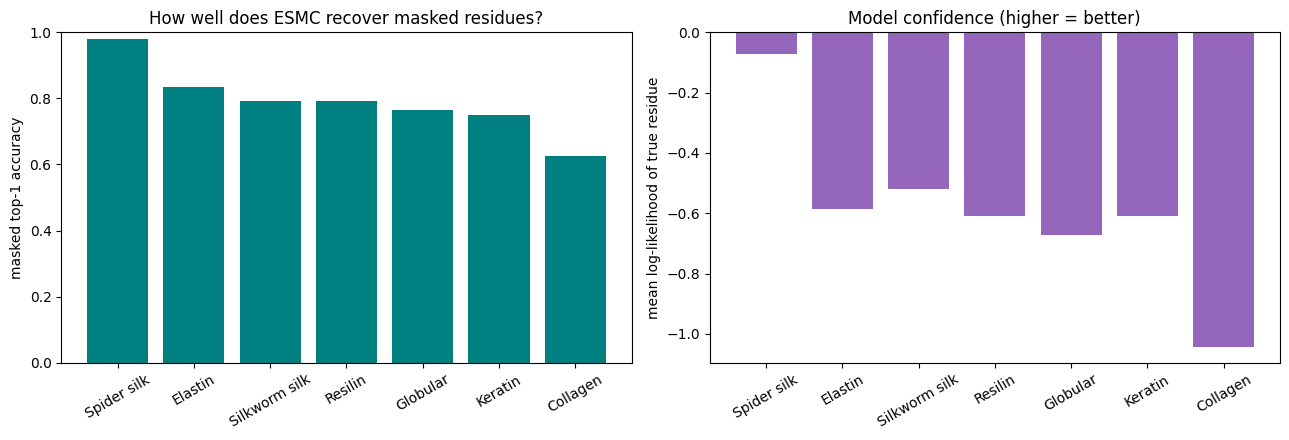

In [11]:
# Plot the family benchmark: recovery accuracy and mean log-likelihood
fams_b = sorted(bench, key=lambda f: bench[f][0], reverse=True)
acc = [bench[f][0] for f in fams_b]; ll = [bench[f][1] for f in fams_b]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.bar(fams_b, acc, color="teal"); a1.set_ylabel("masked top-1 accuracy")
a1.set_title("How well does ESMC recover masked residues?"); a1.set_ylim(0, 1)
a2.bar(fams_b, ll, color="tab:purple"); a2.set_ylabel("mean log-likelihood of true residue")
a2.set_title("Model confidence (higher = better)")
for a in (a1, a2): a.tick_params(axis="x", rotation=30)
plt.tight_layout(); savefig(fig, "05_masked_family_benchmark"); plt.show()

## 6 · Per-residue "naturalness" (pseudo-log-likelihood)

For every position we can read off the model's probability of the residue that is *actually*
there. Low probability = "surprising"/unusual to the model. Averaged over a protein this is a
rough **naturalness** score; per-position it highlights which residues the model considers
canonical for that context. (Here we use a single forward pass — a fast, unmasked approximation.)

In [12]:
@torch.inference_mode()
def residue_logprobs(seq):
    """Per-residue log P(observed residue) under ESMC (single pass). Returns array (L,)."""
    inputs = tokenizer(seq, return_tensors="pt").to(DEVICE)
    ids = inputs["input_ids"][0]
    logp = esmc(**inputs).logits[0].log_softmax(-1)  # (L+2, vocab)
    out = [float(logp[t, ids[t]]) for t in range(1, len(ids) - 1)]
    return np.array(out)

def naturalness(seq):
    return residue_logprobs(seq).mean()

for name in ["MaSp1 repeat", "MaSp2 repeat", "Fibroin (GAGAGS)", "Poly-Ala"]:
    print(f"{name:20} mean log-likelihood = {naturalness(CONSENSUS[name]):+.3f}")
print(f"{'Ubiquitin':20} mean log-likelihood = {naturalness(CONTROLS['Ubiquitin']):+.3f}")

MaSp1 repeat         mean log-likelihood = -0.278
MaSp2 repeat         mean log-likelihood = -0.164
Fibroin (GAGAGS)     mean log-likelihood = -0.039
Poly-Ala             mean log-likelihood = -0.117
Ubiquitin            mean log-likelihood = -0.023


saved: results/06_surprisal_masp2.png and .svg


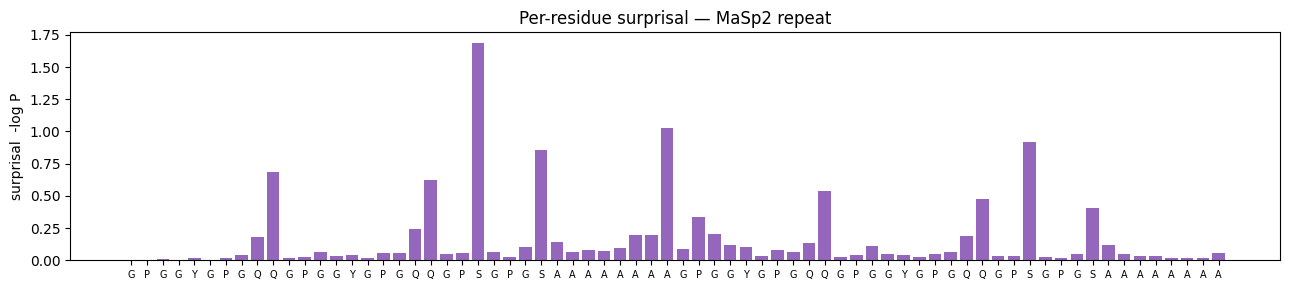

In [13]:
# Plot per-residue surprisal along a silk repeat: troughs = highly expected residues
seq = CONSENSUS["MaSp2 repeat"]
lp = residue_logprobs(seq)
fig, ax = plt.subplots(figsize=(13, 3))
ax.bar(range(len(seq)), -lp, color="tab:purple")
ax.set_xticks(range(len(seq))); ax.set_xticklabels(list(seq), fontsize=7)
ax.set_ylabel("surprisal  -log P"); ax.set_title("Per-residue surprisal — MaSp2 repeat")
plt.tight_layout(); savefig(fig, "06_surprisal_masp2"); plt.show()

## 7 · In-silico deep mutational scan

A classic pLM application: estimate the effect of every possible point mutation. For each
position we **mask** it and read the model's log-probability for all 20 amino acids; the
**log-likelihood ratio** `log P(mut) − log P(wt)` is a zero-shot estimate of how tolerated a
substitution is (positive = model prefers it, negative = disfavored). We scan a window of a
spider-silk repeat — watch the poly-alanine crystalline block.

saved: results/07_mutational_scan_masp1.png and .svg


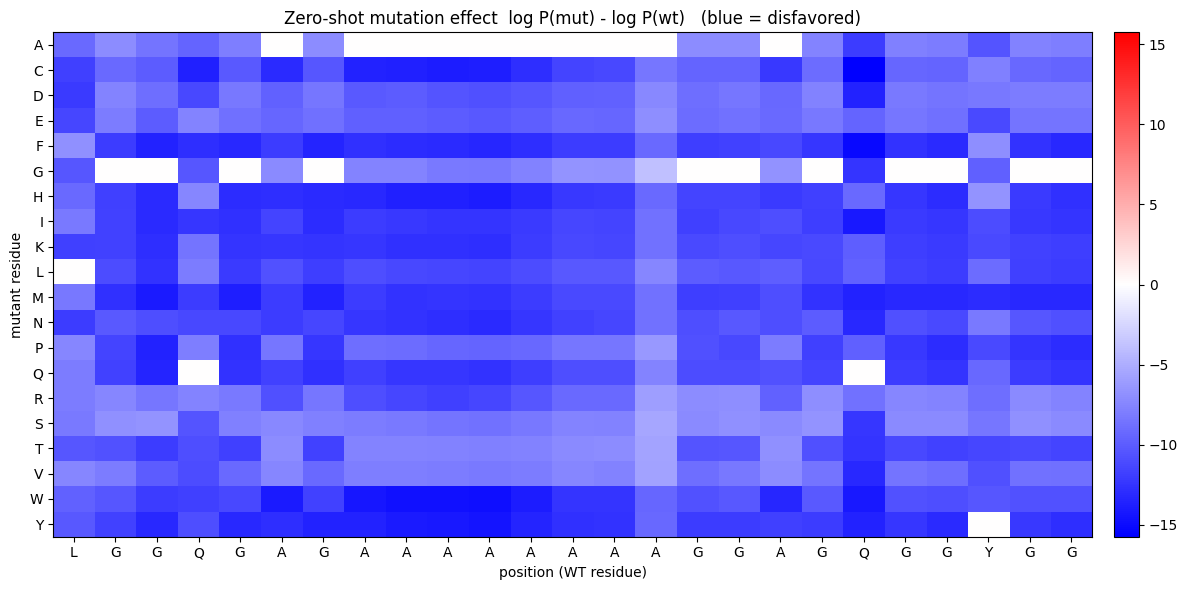

In [14]:
@torch.inference_mode()
def mutational_scan(seq, start, end):
    """LLR matrix (20 x window) of masked-marginal substitution scores."""
    mat = np.zeros((20, end - start))
    base_ids = tokenizer(seq, return_tensors="pt")["input_ids"]
    for j, pos in enumerate(range(start, end)):
        tpos = pos + 1
        ids = base_ids.clone(); ids[0, tpos] = tokenizer.mask_token_id
        logp = esmc(input_ids=ids.to(DEVICE)).logits[0, tpos].log_softmax(-1)
        wt_id = base_ids[0, tpos].item()
        for i, aa in enumerate(AAS):
            mat[i, j] = float(logp[AA_IDS[aa]] - logp[wt_id])
    return mat

seq = CONSENSUS["MaSp1 repeat"]
start, end = 20, 45                         # spans GGX -> into the poly-Ala block
mat = mutational_scan(seq, start, end)

fig, ax = plt.subplots(figsize=(12, 6))
vmax = np.abs(mat).max()
im = ax.imshow(mat, aspect="auto", cmap="bwr", vmin=-vmax, vmax=vmax)
ax.set_yticks(range(20)); ax.set_yticklabels(list(AAS))
ax.set_xticks(range(end - start)); ax.set_xticklabels(list(seq[start:end]))
ax.set_xlabel("position (WT residue)"); ax.set_ylabel("mutant residue")
ax.set_title("Zero-shot mutation effect  log P(mut) - log P(wt)   (blue = disfavored)")
fig.colorbar(im, fraction=0.025, pad=0.02); plt.tight_layout()
savefig(fig, "07_mutational_scan_masp1"); plt.show()

**Discuss:** Inside the poly-alanine crystalline block, which substitutions does ESMC
tolerate? (Glycine? other small residues?) Compare with the glycine-rich region. This mirrors
what is known experimentally: the `(A)n` blocks form tightly packed β-sheet nanocrystals where
side-chain size is strongly constrained.

## 8 · Attention maps — the model "sees" the repeat period

Transformer attention often reflects sequence structure. For a periodic silk repeat we expect
banded/periodic attention; for a globular protein we expect a more irregular pattern. We average
attention over heads in the last layer and compare several sequences side by side, with the
amino acids labeled on both axes. (`output_attentions=True` uses a slower path, so we keep the
sequences short and legible.)

saved: results/08_attention_maps.png and .svg


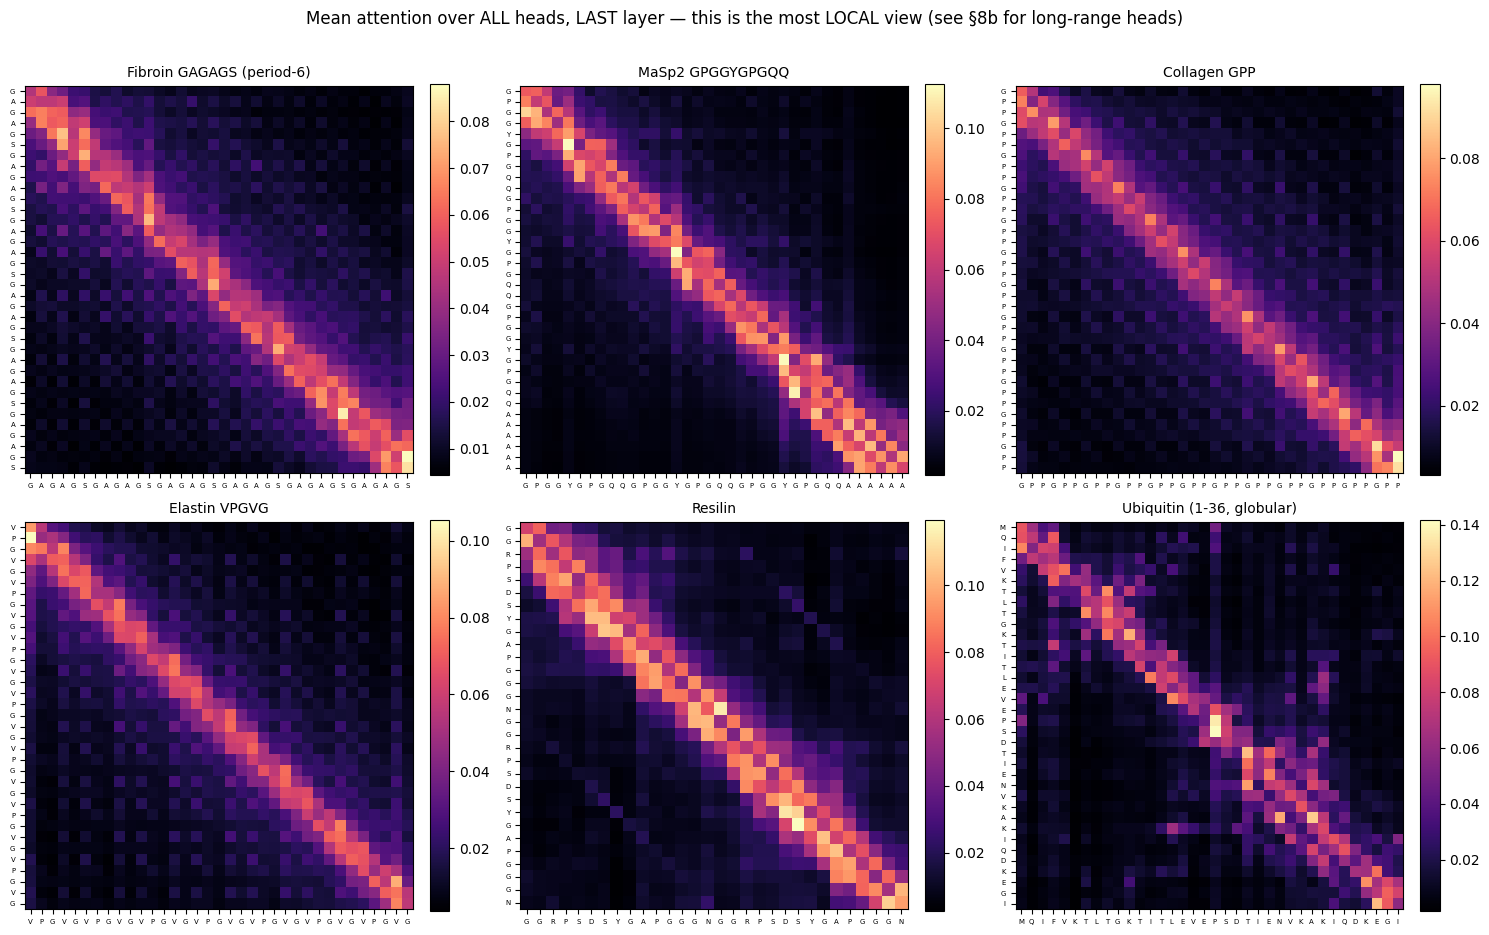

In [15]:
@torch.inference_mode()
def attention_map(seq, layer=-1, head=None):
    """Residue×residue attention. head=None -> mean over ALL heads; else a single head index."""
    inputs = tokenizer(seq, return_tensors="pt").to(DEVICE)
    att = esmc(**inputs, output_attentions=True).attentions[layer][0]   # (H, L+2, L+2)
    A = att.mean(0) if head is None else att[head]
    return A[1:-1, 1:-1].float().cpu().numpy()                           # residues only

# short, legible sequences spanning materials + a globular control
att_seqs = {
    "Fibroin GAGAGS (period-6)": "GAGAGS" * 6,
    "MaSp2 GPGGYGPGQQ":          "GPGGYGPGQQ" * 3 + "AAAAAA",
    "Collagen GPP":              "GPP" * 12,
    "Elastin VPGVG":             "VPGVG" * 7,
    "Resilin":                   "GGRPSDSYGAPGGGN" * 2,
    "Ubiquitin (1-36, globular)": CONTROLS["Ubiquitin"][:36],
}

n = len(att_seqs); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 4.6 * nrow))
for ax, (title, seq) in zip(axes.ravel(), att_seqs.items()):
    A = attention_map(seq)                          # default: mean over heads, LAST layer
    im = ax.imshow(A, cmap="magma")
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(len(seq))); ax.set_xticklabels(list(seq), fontsize=5)
    ax.set_yticks(range(len(seq))); ax.set_yticklabels(list(seq), fontsize=5)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.suptitle("Mean attention over ALL heads, LAST layer — this is the most LOCAL view "
             "(see §8b for long-range heads)", y=1.01)
plt.tight_layout(); savefig(fig, "08_attention_maps"); plt.show()

### 8b · Individual heads & middle layers reveal long-range structure

The maps above average all heads of the **last** layer — the most *local* view, so they look almost
diagonal. The interesting long-range / contact-like attention lives in **individual heads**, usually in
**middle layers**, and is clearest for a **folded (globular)** protein (silk repeats are disordered, so
there are few real long-range contacts to find).

Below we show **every head of a middle layer** for ubiquitin. Watch for **off-diagonal** bright spots:
residues far apart in sequence that attend to each other — a fingerprint of 3-D contacts. Change
`LAYER` / the sequence to explore.

saved: results/08b_attention_heads_ubiquitin.png and .svg


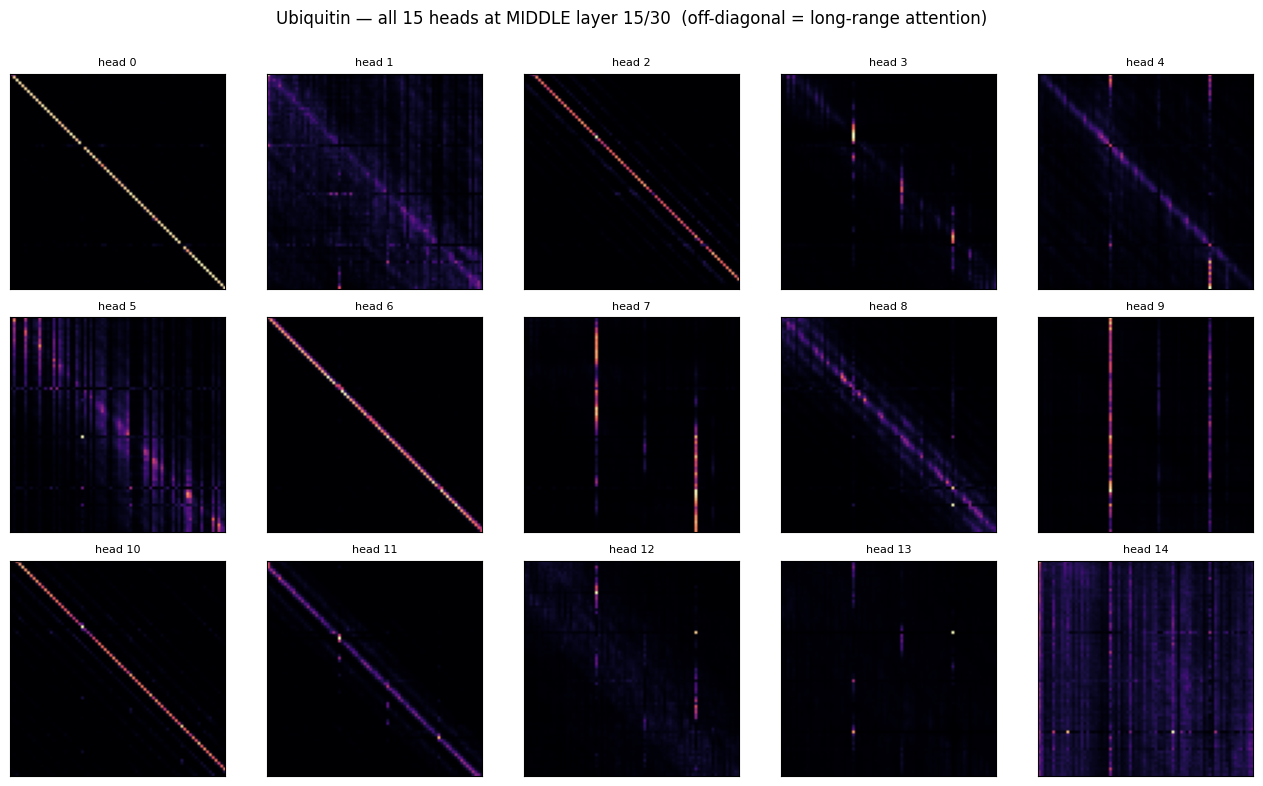

In [16]:
# Every head of a MIDDLE layer for a folded protein -> long-range structure becomes visible
seq = CONTROLS["Ubiquitin"]                                   # full 76-aa folded protein
inputs = tokenizer(seq, return_tensors="pt").to(DEVICE)
with torch.inference_mode():
    att = esmc(**inputs, output_attentions=True).attentions   # tuple: n_layers x (1, H, L+2, L+2)
n_layers, n_heads = len(att), att[0].shape[1]
LAYER = n_layers // 2                                         # a middle layer (try others!)
maps = att[LAYER][0, :, 1:-1, 1:-1].float().cpu().numpy()     # (H, L, L)

ncol = 5; nrow = int(np.ceil(n_heads / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(2.6 * ncol, 2.6 * nrow))
for h, ax in enumerate(axes.ravel()):
    if h < n_heads:
        ax.imshow(maps[h], cmap="magma"); ax.set_title(f"head {h}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Ubiquitin — all {n_heads} heads at MIDDLE layer {LAYER}/{n_layers}  "
             f"(off-diagonal = long-range attention)", y=1.002)
plt.tight_layout(); savefig(fig, "08b_attention_heads_ubiquitin"); plt.show()

## 9 · Structure prediction with **ESMFold2**

Now we go from sequence to **3-D structure**. ESMFold2-Fast predicts all-atom coordinates plus
confidence scores (**pLDDT** per residue, **pTM** overall) directly from a single sequence.

> **Heads-up on resources & precision.** ESMFold2 runs on top of the **6B-parameter ESMC**
> backbone, so the first call downloads **~25 GB** (cached afterwards) and needs lots of RAM/VRAM.
>
> The model is written for **CUDA + bf16 autocast**. With no GPU we run it differently:
> * **Apple-Silicon MPS is not usable** here — ESMFold2 calls ops MPS lacks (e.g. `int64 scatter_reduce_`).
> * On **CPU** we cast the whole model to **float32** (`.float()`), which unifies the bf16 LM
>   backbone with the fp32 folding trunk so CPU linear-algebra ops work. With enough RAM this is fine.
>
> The cell is guarded (`FOLD=False`) so all the language-model sections above still run on any machine.

In [17]:
from contextlib import nullcontext
FOLD = True            # set False to skip the heavy structure-prediction section
FOLD_STEPS = 50        # diffusion sampling steps (README default 50; lower = faster, rougher)
FOLD_LOOPS = 3         # trunk recycles (README default 3)

# ---- Choose an ESMFold2 variant: un-comment exactly ONE line ----
FOLD_MODEL = "biohub/ESMFold2-Fast"  # single-sequence, inference-optimized (default)
# FOLD_MODEL = "biohub/ESMFold2"     # MSA-capable, larger; same 6B ESMC backbone

# ESMFold2 needs CUDA; otherwise fall back to CPU in float32 (MPS lacks required ops).
FOLD_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if FOLD:
    from transformers.models.esmfold2.modeling_esmfold2 import ESMFold2Model
    from esm.models.esmfold2 import ESMFold2InputBuilder, ProteinInput, StructurePredictionInput

    fold_model = ESMFold2Model.from_pretrained(FOLD_MODEL).to(FOLD_DEVICE)
    if FOLD_DEVICE != "cuda":
        fold_model = fold_model.float()       # unify bf16 backbone + fp32 trunk for CPU
    fold_model = fold_model.eval()

    def fold_protein(seq, num_loops=FOLD_LOOPS, num_sampling_steps=FOLD_STEPS, seed=0):
        """Fold a single protein chain -> ESMFold2 result (has .plddt, .ptm, .complex)."""
        spi = StructurePredictionInput(sequences=[ProteinInput(id="A", sequence=seq)])
        amp = (torch.autocast(device_type="cuda", dtype=torch.bfloat16)
               if FOLD_DEVICE == "cuda" else nullcontext())
        with torch.inference_mode(), amp:
            return ESMFold2InputBuilder().fold(fold_model, spi, num_loops=num_loops,
                        num_sampling_steps=num_sampling_steps, num_diffusion_samples=1, seed=seed)
    print(f"{FOLD_MODEL} ready on {FOLD_DEVICE} (first run downloads the ~25 GB ESMC-6B backbone)")
else:
    print("Folding skipped (FOLD=False).")

Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

biohub/ESMFold2-Fast ready on cpu (first run downloads the ~25 GB ESMC-6B backbone)


In [18]:
# Fold a globular control (ubiquitin) and a spider-silk peptide, then compare confidence.
# pLDDT/pTM are on a 0-1 scale (multiply by 100 for the familiar AlphaFold 0-100 range).
fold_targets = {
    "Ubiquitin (control)": CONTROLS["Ubiquitin"],
    "MaSp1 silk peptide":  CONSENSUS["MaSp1 repeat"],
}

results = {}
if FOLD:
    for name, seq in fold_targets.items():
        res = fold_protein(seq)
        results[name] = res
        print(f"{name:22} len={len(seq):3d}  mean pLDDT={float(res.plddt.mean()):.3f}  "
              f"pTM={float(res.ptm):.3f}")

Loading CCD dictionary from /Users/mbuehler/.cache/huggingface/hub/models--biohub--ESMFold2/snapshots/e1e189d0f5fb70c2693da2332eca4443c0ccccd6/ccd.pkl
Ubiquitin (control)    len= 76  mean pLDDT=0.821  pTM=0.782
MaSp1 silk peptide     len= 70  mean pLDDT=0.408  pTM=0.169


**Interpret the confidence.** A well-folded globular protein like ubiquitin scores a
**high** pLDDT/pTM (≈0.8). The repetitive silk peptide scores **much lower** (≈0.4) — and that is
biologically meaningful: dragline silk is **intrinsically disordered in solution** and only
assembles into ordered β-sheet nanocrystals upon spinning (shear + dehydration). Low single-chain
confidence is a *feature of the biology*, not just a model failure. *Great discussion point.*

saved: results/09_plddt_per_residue.png and .svg


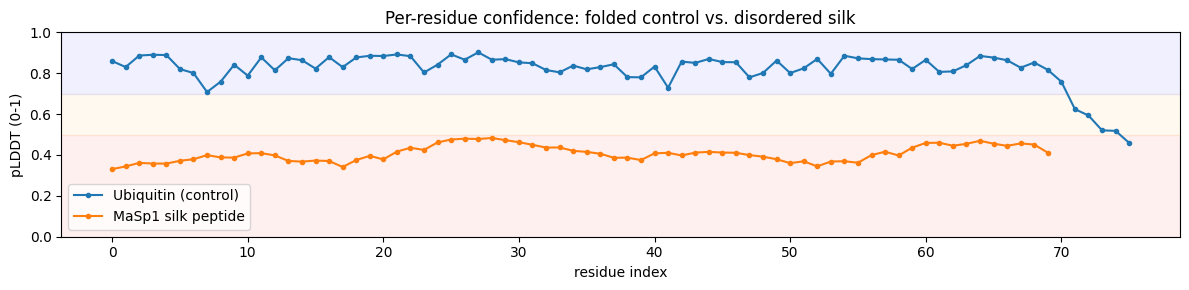

In [19]:
# Per-residue pLDDT, straight from the model (ground truth, 0-1 scale).
if FOLD and results:
    fig, ax = plt.subplots(figsize=(12, 3))
    for name, res in results.items():
        ax.plot(np.asarray(res.plddt).ravel(), marker="o", ms=3, label=name)
    ax.axhspan(0.0, 0.5, color="red",    alpha=0.06)
    ax.axhspan(0.5, 0.7, color="orange", alpha=0.06)
    ax.axhspan(0.7, 1.0, color="blue",   alpha=0.06)
    ax.set_xlabel("residue index"); ax.set_ylabel("pLDDT (0-1)")
    ax.set_title("Per-residue confidence: folded control vs. disordered silk")
    ax.set_ylim(0, 1); ax.legend(); plt.tight_layout()
    savefig(fig, "09_plddt_per_residue"); plt.show()

In [20]:
# 3-D view, colored per-residue by pLDDT (AlphaFold palette). We color from res.plddt
# directly rather than trusting the mmCIF B-factor column.
import py3Dmol

def plddt_color(p):
    if p >= 0.9: return "#0053D6"   # very high
    if p >= 0.7: return "#65CBF3"   # confident
    if p >= 0.5: return "#FFDB13"   # low
    return "#FF7D45"                # very low

def show_structure(res, title="", width=560, height=420):
    cif = res.complex.to_mmcif()
    plddt = np.asarray(res.plddt).ravel()
    view = py3Dmol.view(width=width, height=height)
    view.addModel(cif, "mmcif")
    view.setStyle({"cartoon": {"color": "white"}})
    for i, p in enumerate(plddt):                    # mmCIF residues are 1-indexed
        view.setStyle({"resi": str(i + 1)}, {"cartoon": {"color": plddt_color(float(p))}})
    view.zoomTo()
    print(title + "   (blue = high pLDDT, orange = low)")
    return view.show()

if FOLD and results:
    show_structure(results["Ubiquitin (control)"], "Ubiquitin — folds confidently")

Ubiquitin — folds confidently   (blue = high pLDDT, orange = low)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [21]:
if FOLD and results:
    show_structure(results["MaSp1 silk peptide"], "MaSp1 silk peptide — low confidence (disordered)")

MaSp1 silk peptide — low confidence (disordered)   (blue = high pLDDT, orange = low)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 10 · Transfer learning — train a *new head* on frozen ESMC embeddings

A core use of protein language models is **transfer learning**: freeze the big pretrained model,
use its embeddings as features, and train a small task-specific **head**. We classify a protein's
**material family** from its mean ESMC embedding — the same recipe you'd reuse to predict any
property (stability, solubility, binding, mechanical class, …) given labels.

**What "head" means here.** ESMC stays *frozen* — no gradients flow into it. We attach a brand-new
classifier on top of the 960-d **representation** (the final hidden state), *not* on the masked-LM
logits. Three levels exist; we do the cheapest:

| level | trained | cost |
|-------|---------|------|
| **frozen-feature probe** (this notebook) | a small head only | trivial, any machine |
| head-swap fine-tune (`…ForSequenceClassification`) | head (+ maybe top layers) | moderate |
| **LoRA / full fine-tune** of ESMC | adapters or all weights | heavy (GPU); model card uses `target_modules=["layernorm_qkv.1","out_proj","ffn.1","ffn.3"]` |

**Getting enough data.** A handful of proteins isn't enough to trust an accuracy number, so we
(1) **pull dozens of real sequences per family from UniProt**, and (2) **augment** by slicing each
protein into overlapping windows — turning a few hundred proteins into many more training samples.
We then report **cross-validated** accuracy (mean ± std), not a single lucky split.

In [22]:
import urllib.parse

# One UniProt query per family. Tune N_PER_FAMILY up for more data (and more compute).
N_PER_FAMILY = 40
FAMILY_QUERIES = {
    "Spidroin": "protein_name:spidroin AND length:[80 TO 700]",
    "Fibroin":  "protein_name:fibroin AND length:[80 TO 700]",
    "Collagen": "protein_name:collagen AND reviewed:true AND length:[150 TO 700]",
    "Elastin":  "protein_name:elastin AND reviewed:true AND length:[100 TO 700]",
    "Resilin":  "protein_name:resilin AND length:[80 TO 700]",
    "Keratin":  "protein_name:keratin AND reviewed:true AND length:[100 TO 700]",
    "Globular": '(protein_name:lysozyme OR protein_name:myoglobin OR '
                'protein_name:"cytochrome c") AND reviewed:true AND length:[80 TO 450]',
}

def fetch_family(query, size):
    """Download up to `size` sequences for a UniProt search query."""
    url = (f"https://rest.uniprot.org/uniprotkb/search?query={urllib.parse.quote(query)}"
           f"&format=fasta&size={size}")
    req = urllib.request.Request(url, headers={"User-Agent": "esm-class-notebook"})
    txt = urllib.request.urlopen(req, timeout=60).read().decode()
    seqs, cur = [], []
    for line in txt.splitlines():
        if line.startswith(">"):
            if cur: seqs.append("".join(cur)); cur = []
        else: cur.append(line.strip())
    if cur: seqs.append("".join(cur))
    return [s for s in seqs if 0 < len(s) <= 1000]

def windows(seq, w=200, stride=150, max_windows=4):
    """Slice a sequence into overlapping windows (data augmentation)."""
    if len(seq) <= w: return [seq]
    return [seq[i:i + w] for i in range(0, len(seq) - w + 1, stride)][:max_windows] or [seq[:w]]

aug_seqs, aug_fams, n_proteins = [], [], {}
for fam, q in FAMILY_QUERIES.items():
    prots = fetch_family(q, N_PER_FAMILY)
    n_proteins[fam] = len(prots)
    for s in prots:
        for win in windows(s):
            aug_seqs.append(win); aug_fams.append(fam)
print("proteins fetched per family:", n_proteins)
print(f"after windowing: {len(aug_seqs)} training samples across {len(FAMILY_QUERIES)} families")

proteins fetched per family: {'Spidroin': 40, 'Fibroin': 40, 'Collagen': 40, 'Elastin': 18, 'Resilin': 40, 'Keratin': 40, 'Globular': 40}
after windowing: 471 training samples across 7 families


In [23]:
import torch.nn as nn

@torch.inference_mode()
def embed_batch(seqs, bs=16):
    """Mean-pooled ESMC embeddings for many sequences (batched, pad-masked)."""
    out = []
    for i in range(0, len(seqs), bs):
        enc = tokenizer(seqs[i:i + bs], return_tensors="pt", padding=True).to(DEVICE)
        h = esmc(**enc, output_hidden_states=True).hidden_states[-1]         # (B, L, 960)
        m = enc["attention_mask"].clone().float(); m[:, 0] = 0               # drop <cls>
        for r, L in enumerate(enc["attention_mask"].sum(1)):
            m[r, int(L) - 1] = 0                                             # drop <eos>
        out.append(((h * m.unsqueeze(-1)).sum(1) / m.sum(1, keepdim=True)).float().cpu())
    return torch.cat(out).numpy()

FAM_LIST = list(FAMILY_QUERIES)
Xaug = embed_batch(aug_seqs).astype("float32")
yaug = np.array([FAM_LIST.index(f) for f in aug_fams])
print("embedded augmented dataset:", Xaug.shape)

embedded augmented dataset: (471, 960)


Linear probe — 5-fold CV accuracy: 0.94 +/- 0.02  (chance = 0.14)
MLP head — held-out accuracy: 0.94
saved: results/10_transfer_head.png and .svg


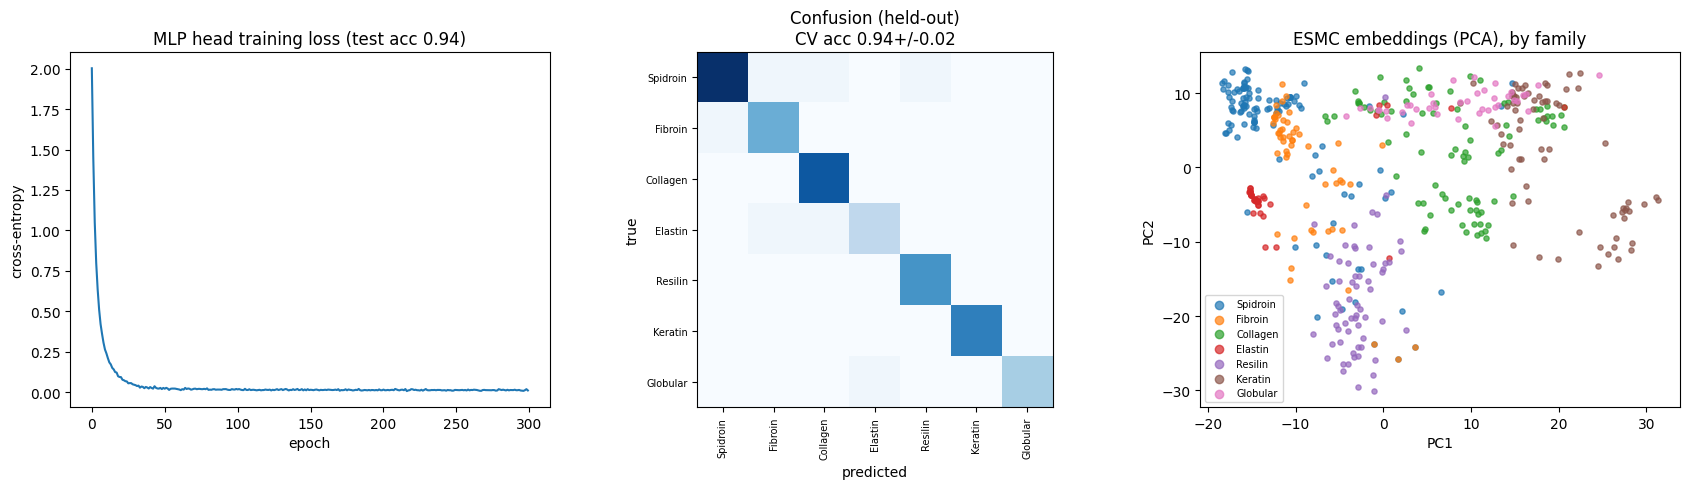

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA

# (1) Honest metric: cross-validated LINEAR PROBE (logistic regression on frozen features)
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
cv_scores = cross_val_score(clf, Xaug, yaug, cv=cv)
print(f"Linear probe — 5-fold CV accuracy: {cv_scores.mean():.2f} +/- {cv_scores.std():.2f}  "
      f"(chance = {1/len(FAM_LIST):.2f})")

# (2) "Train a head" mechanic: a torch MLP head on a train/test split, with a loss curve
Xtr, Xte, ytr, yte = train_test_split(Xaug, yaug, test_size=0.25, stratify=yaug, random_state=0)
sc = StandardScaler().fit(Xtr)
Xtr_t = torch.tensor(sc.transform(Xtr), dtype=torch.float32)
Xte_t = torch.tensor(sc.transform(Xte), dtype=torch.float32)
ytr_t = torch.tensor(ytr, dtype=torch.long)
torch.manual_seed(0)
head = nn.Sequential(nn.Linear(Xaug.shape[1], 128), nn.ReLU(), nn.Dropout(0.3),
                     nn.Linear(128, len(FAM_LIST)))
opt = torch.optim.Adam(head.parameters(), lr=1e-3, weight_decay=1e-4)
lossfn = nn.CrossEntropyLoss(); losses = []
for epoch in range(300):
    head.train(); opt.zero_grad()
    loss = lossfn(head(Xtr_t), ytr_t); loss.backward(); opt.step(); losses.append(loss.item())
head.eval()
with torch.no_grad():
    pred_te = head(Xte_t).argmax(1).numpy()
mlp_acc = (pred_te == yte).mean()
print(f"MLP head — held-out accuracy: {mlp_acc:.2f}")

# (3) Plots: loss curve | confusion matrix | PCA of the embeddings colored by family
cm = confusion_matrix(yte, pred_te, labels=range(len(FAM_LIST)))
xy = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(Xaug))
fig, ax = plt.subplots(1, 3, figsize=(17, 5))
ax[0].plot(losses); ax[0].set_title(f"MLP head training loss (test acc {mlp_acc:.2f})")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("cross-entropy")
im = ax[1].imshow(cm, cmap="Blues")
ax[1].set_title(f"Confusion (held-out)\nCV acc {cv_scores.mean():.2f}+/-{cv_scores.std():.2f}")
ax[1].set_xticks(range(len(FAM_LIST))); ax[1].set_xticklabels(FAM_LIST, rotation=90, fontsize=7)
ax[1].set_yticks(range(len(FAM_LIST))); ax[1].set_yticklabels(FAM_LIST, fontsize=7)
ax[1].set_xlabel("predicted"); ax[1].set_ylabel("true")
for fi, fam in enumerate(FAM_LIST):
    idx = yaug == fi
    ax[2].scatter(xy[idx, 0], xy[idx, 1], s=14, alpha=0.7, label=fam)
ax[2].set_title("ESMC embeddings (PCA), by family")
ax[2].set_xlabel("PC1"); ax[2].set_ylabel("PC2"); ax[2].legend(fontsize=7, markerscale=1.6)
plt.tight_layout(); savefig(fig, "10_transfer_head"); plt.show()

## 11 · Interactive exploration — a sequence-relatedness graph

A nice way to *mine* the embedding space is to turn it into a **graph**: each protein is a node,
and we draw an **edge between two proteins when their ESMC embeddings are similar** (cosine ≥ a
threshold), optionally always linking each protein to its *k* nearest neighbors. Proteins that the
model considers related pull together into clusters — a "map of relatedness" learned purely from
sequence. Use the controls to:

* **`threshold`** — raise it to keep only the strongest links (sparser graph), lower it for more edges;
* **`knn`** — always connect each node to its *k* closest proteins (keeps the graph from fragmenting);
* **`highlight`** — pick a protein to spotlight it and its direct neighbors (its "embedding family").

*(Interactive widgets need a live Jupyter kernel; a static export shows the default view, which is
also saved to `results/`.)*

saved: results/11_sequence_graph.png and .svg


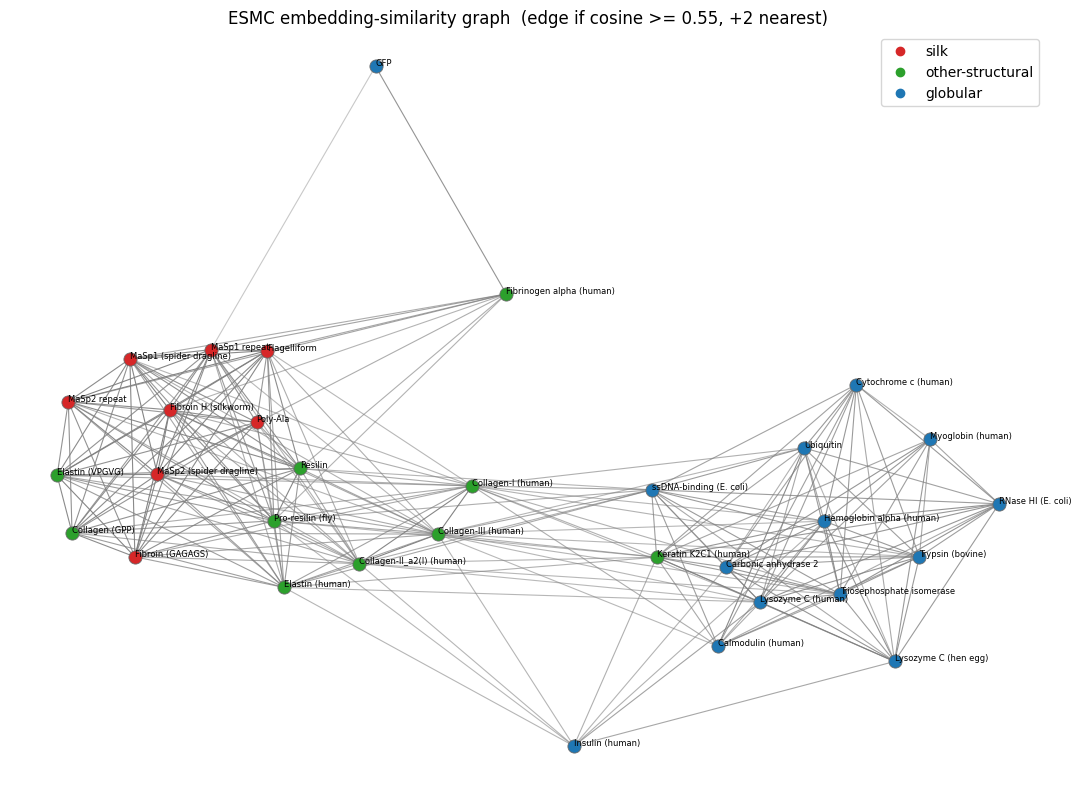

interactive(children=(FloatSlider(value=0.55, description='threshold', max=0.95, min=0.3, step=0.05), IntSlide…

In [25]:
import networkx as nx
import ipywidgets as widgets

GS = cosine_matrix(embs).copy()            # 32x32 cosine similarities from section 4
np.fill_diagonal(GS, 0.0)
FAM_COLOR = {"silk": "tab:red", "other-structural": "tab:green", "globular": "tab:blue"}

def build_graph(threshold, knn):
    G = nx.Graph(); G.add_nodes_from(range(len(labels)))
    for i in range(len(labels)):
        for j in np.argsort(-GS[i])[:knn]:                 # always link k nearest
            G.add_edge(i, int(j), weight=float(GS[i, int(j)]))
        for j in range(i + 1, len(labels)):                # plus everything above threshold
            if GS[i, j] >= threshold:
                G.add_edge(i, j, weight=float(GS[i, j]))
    return G

def draw_graph(threshold=0.55, knn=2, highlight="(none)", save=False):
    G = build_graph(threshold, knn)
    pos = nx.spring_layout(G, seed=3, weight="weight", k=0.9)
    fig, ax = plt.subplots(figsize=(11, 8))
    for u, v, d in G.edges(data=True):                     # edges, opacity ~ similarity
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color="gray", alpha=float(np.clip(d["weight"], 0.05, 1.0)), lw=0.8, zorder=1)
    hi = labels.index(highlight) if highlight in labels else None
    nbrs = set(G.neighbors(hi)) if hi is not None else set()
    for i, lab in enumerate(labels):
        big, near = (i == hi), (i in nbrs)
        ax.scatter(*pos[i], s=(440 if big else 210 if near else 90), c=FAM_COLOR[fams[i]],
                   edgecolors=("black" if big else "dimgray"),
                   linewidths=(2.4 if big else 0.6), zorder=3)
        ax.annotate(lab, pos[i], fontsize=(8 if (big or near) else 6),
                    fontweight=("bold" if big else "normal"), zorder=4)
    handles = [plt.Line2D([], [], marker="o", ls="", color=c, label=f) for f, c in FAM_COLOR.items()]
    ax.legend(handles=handles, loc="best")
    ax.set_title(f"ESMC embedding-similarity graph  (edge if cosine >= {threshold:.2f}, +{knn} nearest)")
    ax.axis("off"); plt.tight_layout()
    if save: savefig(fig, "11_sequence_graph")
    plt.show()

draw_graph(threshold=0.55, knn=2, save=True)               # static snapshot -> results/
try:
    widgets.interact(
        draw_graph,
        threshold=widgets.FloatSlider(min=0.30, max=0.95, step=0.05, value=0.55),
        knn=widgets.IntSlider(min=0, max=5, step=1, value=2),
        highlight=widgets.Dropdown(options=["(none)"] + labels, value="(none)"),
        save=widgets.fixed(False),
    )
except Exception as e:
    print("Interactive graph needs a live Jupyter kernel. (", e, ")")

### 11b · Bonus: live masked-residue explorer

Pick a sequence and slide along its positions to watch ESMC's top predictions update in real time.

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    explore_seqs = {**CONSENSUS, "Ubiquitin (globular)": CONTROLS["Ubiquitin"],
                    "MaSp2 (real)": real_seqs["MaSp2 (spider dragline)"]}

    def explore(sequence_name, position):
        seq = explore_seqs[sequence_name]
        position = min(position, len(seq) - 1)
        wt, preds = predict_masked(seq, position, topk=8)
        aas = [a for a, _ in preds]; ps = [p for _, p in preds]
        lo, hi = max(0, position - 6), min(len(seq), position + 7)
        ctx = seq[lo:position] + "[" + seq[position] + "]" + seq[position + 1:hi]
        fig, ax = plt.subplots(figsize=(7, 3))
        ax.bar(aas, ps, color=["tab:green" if a == wt else "tab:gray" for a in aas])
        ax.set_ylim(0, 1); ax.set_ylabel("P(residue)")
        ax.set_title(f"{sequence_name}  pos {position}   true={wt}   …{ctx}…")
        plt.tight_layout(); plt.show()

    widgets.interact(
        explore,
        sequence_name=widgets.Dropdown(options=list(explore_seqs), value="MaSp2 repeat"),
        position=widgets.IntSlider(min=0, max=60, step=1, value=18),
    )
except Exception as e:
    print("ipywidgets interactive view needs a live Jupyter kernel. (", e, ")")

interactive(children=(Dropdown(description='sequence_name', index=1, options=('MaSp1 repeat', 'MaSp2 repeat', …

## 12 · Exercises

1. **Embeddings.** Add wool **keratin** (UniProt `P02534`) and a **mussel foot protein** to the
   library. Where do they land in the PCA map? Does keratin (coiled-coil) separate from β-sheet silks?
2. **Grammar.** Mask every position in `GAGAGS×n` one at a time. Which positions are most
   predictable? Does the model "know" the period-6 register?
3. **Design.** Use the mutational scan to propose 3 substitutions in the MaSp1 poly-Ala block that
   ESMC predicts are tolerated, and 3 that are strongly disfavored. Form a hypothesis about why.
4. **Length & confidence.** Fold `(GPGGX)` elastic repeats of increasing length. How does pLDDT
   change? Relate to silk being disordered until spun.
5. **Bigger model.** Re-run §5–§7 with `ESMC-600M`. Do predictions get sharper / more confident?
6. **Real vs consensus.** Compare naturalness of the *real* spidroin slice vs the consensus
   construct. Which does ESMC find more "natural", and why might that be?

## References
- ESMC / ESMFold2 model cards: <https://huggingface.co/biohub/ESMC-6B>, <https://huggingface.co/biohub/ESMFold2>
- Candido et al., *Language Modeling Materializes a World Model of Protein Biology* (2026).
- Spider silk biology: poly-Ala β-nanocrystals + glycine-rich amorphous matrix (MaSp1/MaSp2).
